# Data Visualization
In this notebook, we will explore the dataset generated using [generate_sionna_dataset.py](../scripts/generate_datasets_from_sionna.py)

In [2]:
# Imports

import os
from typing import Optional

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pdb
from cebed.utils import read_metadata
from cebed.datasets.utils import read_dataset_from_file

os.environ["CUDA_VISIBLE_DEVICES"]=""

2025-06-26 15:39:09.809636: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-26 15:39:09.851864: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-26 15:39:09.851897: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-26 15:39:09.852868: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-26 15:39:09.860729: I tensorflow/core/platform/cpu_feature_guar

In [3]:
data_path = "/home/CAMPUS/rghasemi/projects/MyPrivaterepo/CeBed/datasets/ps2_p612/speed5"
assert os.path.isdir(data_path)

In [4]:
# Read data
data = read_dataset_from_file(os.path.join(data_path, "data.hdf5"))
env_config = read_metadata(os.path.join(data_path, "metadata.yaml"))

In [5]:
# Investigate data
# by number of domain we will have data for different SNR(i.e if num_domains  = 5, we will have "size" data for each SNR = 0, 5, 10, 15, 20, 25 )
print(f"Available data {data.keys()}")

print(f"Channels : {data['h'].shape}") # expected shape [num_domains, size, nrof_receivers, nrof_receive_antennas, nrof_transmitters, nrof_transmitter_streams, nrof_ofdm_symbols, nrof_ofdm_subcarriers]
print(f"Number of domains: {len(data['h'])}")

Available data <KeysViewHDF5 ['h', 'x', 'y']>
Channels : (5, 10000, 1, 1, 1, 1, 14, 612)
Number of domains: 5


In [6]:
print(env_config)


EnvConfig(n_ues=1, carrier_frequency=2100000000.0, num_ofdm_symbols=14, fft_size=612, subcarrier_spacing=30000.0, num_rx_antennas=1, scenario='umi', num_bits_per_symbol=2, pilot_pattern='block', pilot_ofdm_symbol_indices=[3, 10], p_spacing=1, path_loss=True, shadowing='True', los=False, direction='uplink', num_streams_per_tx=1, ue_speed=5, dynamic_topology=True, normalize_channel=True)


In [7]:

# Utility function to plot random channels from dataset
def display_complex_channels(tensors:tf.Tensor, sample_size:int=5, mask:Optional[tf.Tensor]=None)->plt.figure:
    
    figure = plt.figure(figsize=(10, 10))
        
    if len(tensors.shape) < 4:
        # add spatial dim if missing
        tensors = tf.expand_dims(tensors, 1)

    ids = np.random.choice(len(tensors), size=sample_size, replace=False)

    if isinstance(mask, tf.Tensor):
        mask = mask.numpy()
        
    for i, idx in enumerate(ids):            
        plt.subplot(sample_size, 2, 2 * i + 1)
        sns.heatmap(tf.math.real(tensors[idx, 0]), mask=mask)
        plt.subplot(sample_size, 2, 2 * i + 2)
        sns.heatmap(tf.math.imag(tensors[idx, 0]), mask=mask)

    return figure

Let's visualize the channels of a given train domain

2025-06-26 15:40:15.631045: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 44861 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:4f:00.0, compute capability: 8.9
2025-06-26 15:40:15.631749: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 46495 MB memory:  -> device: 1, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:52:00.0, compute capability: 8.9
2025-06-26 15:40:15.632250: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 46495 MB memory:  -> device: 2, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:d5:00.0, compute capability: 8.9
2025-06-26 15:40:15.632721: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 44857 MB memory:  -> device: 3, name: NV

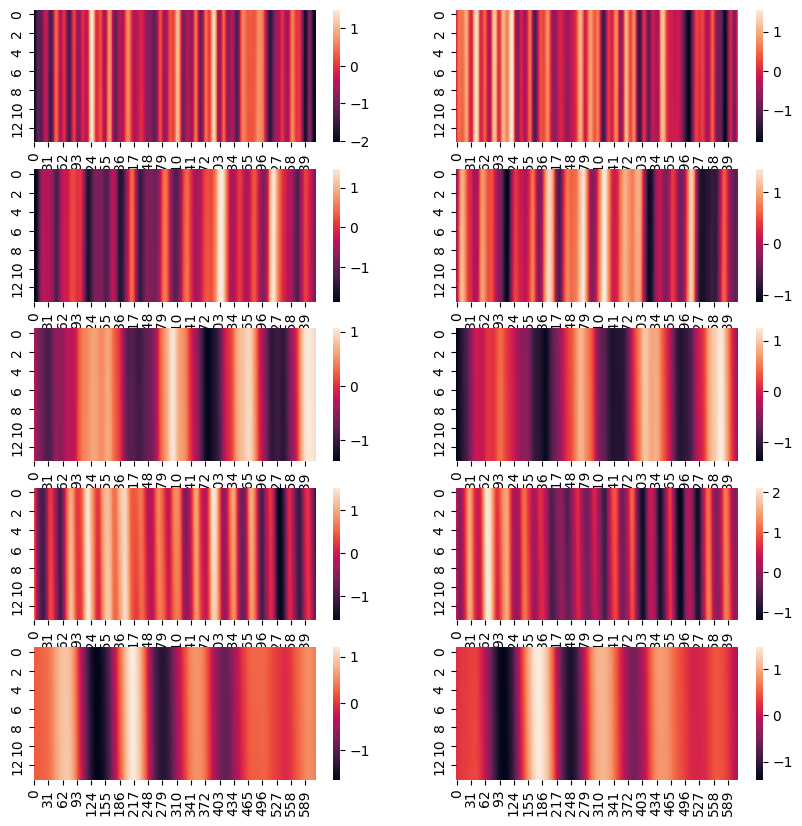

In [8]:
domain_id = 0
figure = display_complex_channels(tf.squeeze(data['h'])[domain_id])
plt.show()

## Investigate the environment

In [ ]:
from cebed.envs import OfdmEnv
from pprint import pprint

env = OfdmEnv(env_config)
pprint(vars(env_config))

{'carrier_frequency': 2100000000.0,
 'direction': 'uplink',
 'dynamic_topology': True,
 'fft_size': 612,
 'los': False,
 'n_ues': 1,
 'normalize_channel': True,
 'num_bits_per_symbol': 2,
 'num_ofdm_symbols': 14,
 'num_rx_antennas': 1,
 'num_streams_per_tx': 1,
 'p_spacing': 1,
 'path_loss': True,
 'pilot_ofdm_symbol_indices': [3, 10],
 'pilot_pattern': 'block',
 'scenario': 'umi',
 'seed': 0,
 'shadowing': 'True',
 'subcarrier_spacing': 30000.0,
 'ue_speed': 5}


: 

[<Figure size 640x480 with 2 Axes>]

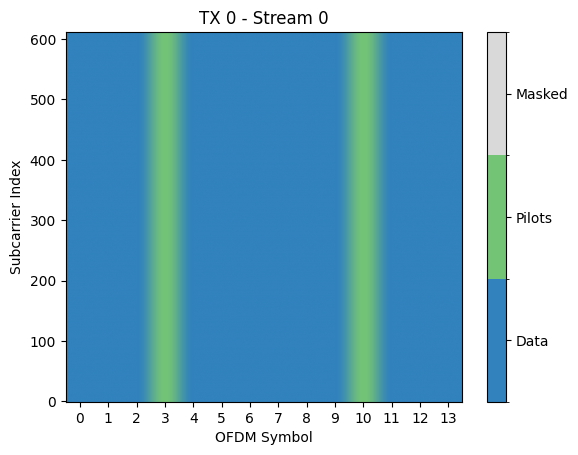

In [9]:
# Visualize the pilot pattern
env.rg.pilot_pattern.show()


### Extract LS estimates (model inputs)

In [12]:
received_signals = np.array(data['y'][:])
inputs = env.estimate_at_pilot_locations(received_signals[domain_id])

In [13]:
inputs

<tf.Tensor: shape=(10000, 1, 1, 1, 1, 14, 612), dtype=complex64, numpy=
array([[[[[[[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            ...,
            [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]]]]]],





       [[[[[[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            ...,
            [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
            [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]]]]]],





       [[[[[[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
   

In [17]:
print(tf.squeeze(inputs).shape)

(10000, 14, 612)


(14, 612)


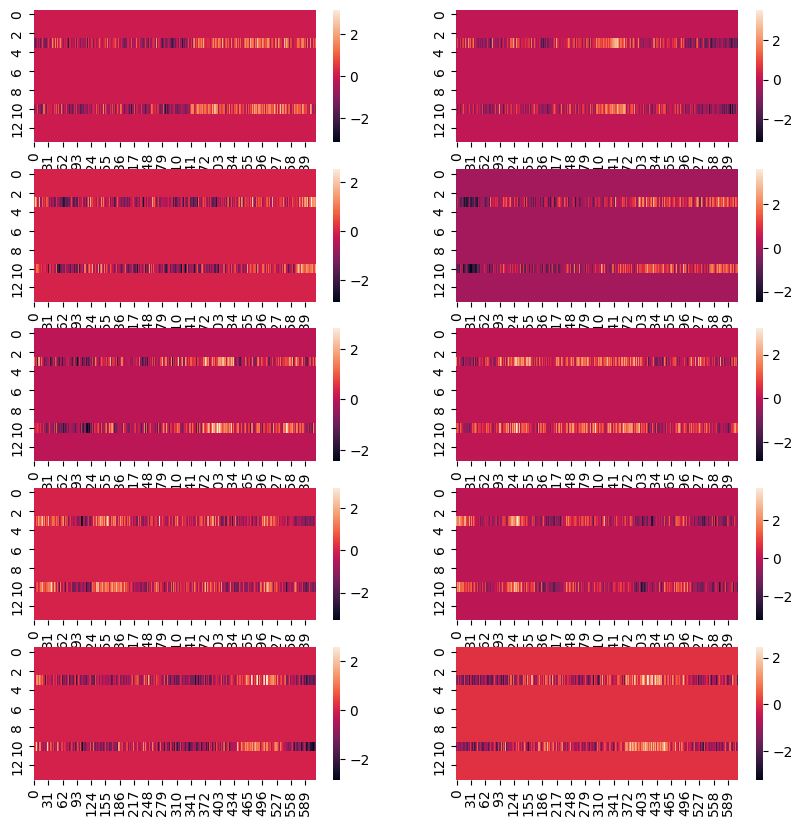

In [19]:
mask = tf.squeeze(env.rg.pilot_pattern.mask)
print(mask.shape)
figure = display_complex_channels(tf.squeeze(inputs), mask=None)
plt.show()